# End-to-end CO Reprojection and Gridding (Worked Example)

This notebook walks through the full processing chain **step by step**, explaining what happens at each stage and **visualizing intermediate results**.

We start from a swath-like S5P product (latitude/longitude points), apply **QA filtering**, **regular gridding in lat/lon**, **reprojection to EQUI7 Europe**, and finish with a **spatial subset and time dimension**.

---

## 0. Imports and helper functions

We first import all required libraries and define helper functions used throughout the workflow.



In [34]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.interpolate import griddata
from pyproj import Transformer
from shapely import box

import rasterio
from rasterio.transform import from_origin
from rasterio.warp import calculate_default_transform, reproject, Resampling

### Helper: pixel center coordinates

This function computes **map coordinates of pixel centers** from an affine transform.



In [35]:
def pixel_center_coords(transform, width, height):
    cols = np.arange(width)
    rows = np.arange(height)

    xs = transform.c + cols * transform.a
    ys = transform.f + rows * transform.e

    return xs, ys


## 1. Reprojection from WGS84 to EQUI7 (Europe)

We reproject a **2D NumPy array** defined on a regular lat/lon grid into **EQUI7 Europe (EPSG:27704)** with a fixed output resolution.

Key ideas:

* Define the **source affine transform** from lat/lon vectors
* Compute a matching **destination grid**
* Use `rasterio.warp.reproject`

In [36]:
def reproject_numpy_to_equi7_eu_1km(
    data, lons, lats, nodata=np.nan, resampling="bilinear"
):

    assert data.ndim == 2 and data.shape == (len(lats), len(lons))

    # Ensure north-up orientation
    if lats[0] < lats[-1]:
        data = data[::-1, :]
        lats = lats[::-1]

    xres = float(abs(lons[1] - lons[0]))
    yres = float(abs(lats[1] - lats[0]))
    west = float(lons.min())
    north = float(lats.max())

    src_transform = from_origin(west - xres/2, north + yres/2, xres, yres)
    src_crs = "EPSG:4326"

    dst_crs = "EPSG:27704"
    out_res = 10000.0  # 10 km

    left, bottom, right, top = rasterio.transform.array_bounds(
        data.shape[0], data.shape[1], src_transform
    )

    dst_transform, dst_w, dst_h = calculate_default_transform(
        src_crs, dst_crs,
        data.shape[1], data.shape[0],
        left, bottom, right, top,
        resolution=out_res
    )

    from math import floor
    x0 = floor(dst_transform.c / out_res) * out_res
    y0 = floor(dst_transform.f / out_res) * out_res
    dst_transform = rasterio.Affine(out_res, 0, x0, 0, -out_res, y0)

    dst = np.full((dst_h, dst_w), nodata, dtype=data.dtype)

    reproject(
        source=data,
        destination=dst,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=getattr(Resampling, resampling),
        src_nodata=nodata,
        dst_nodata=nodata,
    )

    return dst, dst_transform, dst_crs

## 2. Time-wise merging of multiple swaths

When processing multiple overpasses, we want to **align datasets and average values per sensing day**.

In [37]:
def merge_mean_by_time(datasets):
    ds_aligned = xr.align(*datasets, join="outer")
    ds_cat = xr.concat(ds_aligned, dim="time")
    ds_out = ds_cat.groupby("time").mean(skipna=True)
    return ds_out.sortby("time")

In [38]:
datasets = []

path = "/home/simon/eodc_datasync/products/copernicus.eu/.incoming/s5p/S5P_OFFL_L2__CO_____20240817T112455_20240817T130625_35470_03_020600_20240819T093718.nc"

## 3. Reading and filtering a CO product

We now load a Sentinel-5P product and apply:

* QA filtering
* Geographic bounding box (Austria)
* Coordinate cleanup


In [39]:
ds = xr.open_dataset(path, engine="netcdf4", group="PRODUCT")
is_no2 = False
qa_threshold = 0.5

getfattr: /home/simon/eodc_datasync/products/copernicus.eu/.incoming/s5p/S5P_OFFL_L2__CO_____20240817T112455_20240817T130625_35470_03_020600_20240819T093718.nc: Operation not supported


## 4. Define Austria bounding box

We compute the geographic extent by transforming from EQUI7 Europe back to WGS84.

In [40]:
transformer = Transformer.from_crs("EPSG:27704", "EPSG:4326", always_xy=True)

lon_max, lat_max = transformer.transform(5700000, 2100000)
lon_min, lat_min = transformer.transform(4200000, 900000)

austria_bbox = box(lon_min, lat_min, lon_max, lat_max)

## 5. QA and spatial filtering

Only pixels inside Austria **and** with sufficient QA are kept.

In [41]:
ds = ds.load()
ds = ds.set_coords(["longitude", "latitude"])

delta_time = ds[["delta_time", "latitude", "longitude"]]
ds = ds.drop_vars(["delta_time", "time_utc"])

mask = (
    (ds["latitude"] >= lat_min) & (ds["latitude"] <= lat_max) &
    (ds["longitude"] >= lon_min) & (ds["longitude"] <= lon_max) &
    (ds["qa_value"] >= qa_threshold)
)

mask_qa = (
    (ds["latitude"] >= lat_min) & (ds["latitude"] <= lat_max) &
    (ds["longitude"] >= lon_min) & (ds["longitude"] <= lon_max)
)
ds_qa = ds.where(mask_qa, drop=True)
ds_qa = ds_qa.rio.write_crs("EPSG:4326", inplace=False)
ds_subset = ds.where(mask, drop=True)
ds_subset = ds_subset.rio.write_crs("EPSG:4326", inplace=False)

In [42]:
ds

<xarray.Dataset> Size: 22MB
Dimensions:                                (time: 1, scanline: 4173,
                                            ground_pixel: 215, corner: 4,
                                            layer: 50)
Coordinates:
  * time                                   (time) datetime64[ns] 8B 2024-08-17
  * scanline                               (scanline) float64 33kB 0.0 ... 4....
  * ground_pixel                           (ground_pixel) float64 2kB 0.0 ......
  * corner                                 (corner) float64 32B 0.0 1.0 2.0 3.0
  * layer                                  (layer) float32 200B 4.95e+04 ... ...
    latitude                               (time, scanline, ground_pixel) float32 4MB ...
    longitude                              (time, scanline, ground_pixel) float32 4MB ...
Data variables:
    qa_value                               (time, scanline, ground_pixel) float32 4MB ...
    carbonmonoxide_total_column            (time, scanline, ground_pixel) float32 4MB ...
    carbonmonoxide_total_column_precision  (time, scanline, ground_pixel) float32 4MB ...
    carbonmonoxide_total_column_corrected  (time, scanline, ground_pixel) float32 4MB ...

## 6. Visualization: filtered swath points

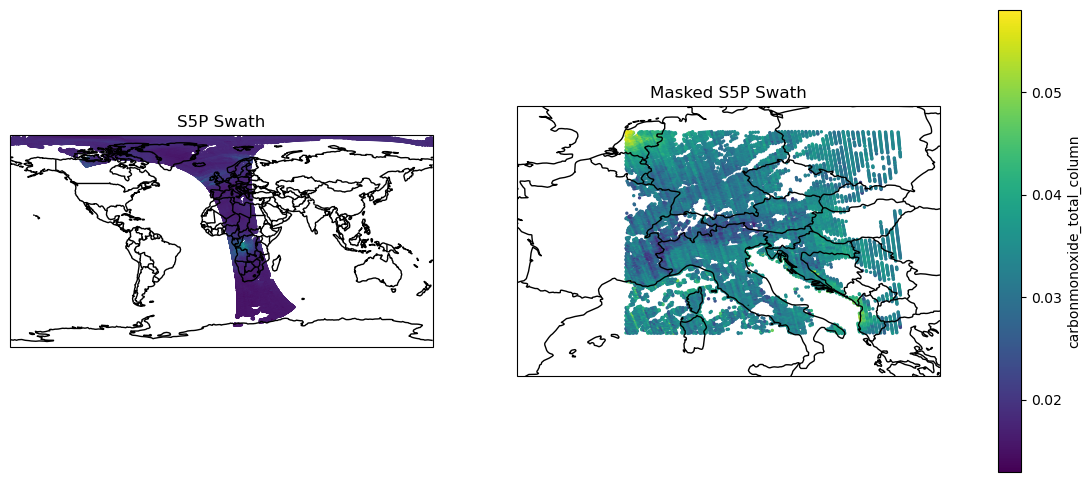

In [51]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

ax0 = axes[0]
ax0.coastlines()
ax0.add_feature(cfeature.BORDERS)

sc0 = ax0.scatter(
    ds.longitude,
    ds.latitude,
    c=ds["carbonmonoxide_total_column"],
    s=2,
    transform=ccrs.PlateCarree(),
)

ax0.set_title("S5P Swath")
ax1 = axes[1]
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS)

sc1 = ax1.scatter(
    ds_qa.longitude,
    ds_qa.latitude,
    c=ds_qa["carbonmonoxide_total_column"],
    s=2,
    transform=ccrs.PlateCarree(),
)

ax1.set_title("Masked S5P Swath")

cbar = fig.colorbar(sc1, ax=axes, orientation="vertical", label="carbonmonoxide_total_column")

plt.show()

## 7. Regular lat/lon gridding (0.1°)

We interpolate irregular swath points onto a **regular geographic grid**.

In [44]:
ds_band = ds_subset.squeeze()

lat_original = ds_band["latitude"]
lon_original = ds_band["longitude"]

lat_min, lat_max = lat_original.min().item(), lat_original.max().item()
lon_min, lon_max = lon_original.min().item(), lon_original.max().item()
lat_min, lat_max, lon_min, lon_max

target_resolution = 0.1

n_points_lat_full = int(np.ceil((lat_max - lat_min) / target_resolution)) + 1
n_points_lon_full = int(np.ceil((lon_max - lon_min) / target_resolution)) + 1
target_lat_full = np.linspace(lat_min, lat_max, n_points_lat_full)
target_lon_full = np.linspace(lon_min, lon_max, n_points_lon_full)
lon_grid_full, lat_grid_full = np.meshgrid(target_lon_full, target_lat_full)

gridded_data = {}

for var in ds_band.data_vars:
    if var == "qa_value":
        gridded = griddata((lon_original.values.flatten(), lat_original.values.flatten()),
                                    ds_band[var].values.flatten(),
                                    (lon_grid_full, lat_grid_full),
                                    method="nearest")
        
    else:
        gridded = griddata((lon_original.values.flatten(), lat_original.values.flatten()),
                                        ds_band[var].values.flatten(),
                                        (lon_grid_full, lat_grid_full),
                                        method="linear")

    gridded_data[var] = gridded

## 8. Visualization: gridded lat/lon field

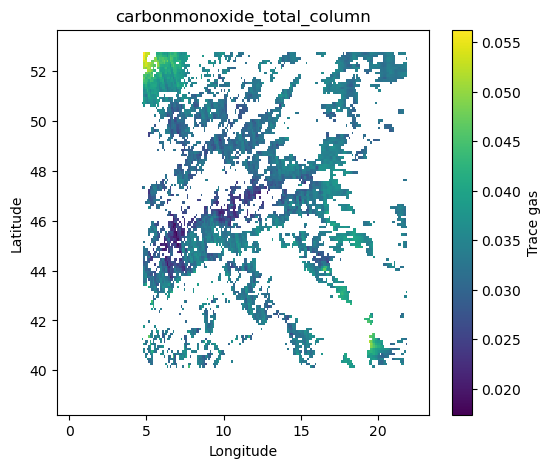

In [45]:
plt.figure(figsize=(6, 5))
plt.pcolormesh(lon_grid_full, lat_grid_full, gridded_data[list(gridded_data)[1]], shading="auto")
plt.colorbar(label="Trace gas")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("carbonmonoxide_total_column")
plt.show()

## 9. Reprojection to EQUI7 Europe

Each variable is now reprojected to a **10 km EQUI7 grid**.

In [46]:
reprojected = {}

for var in gridded_data:
    if var == "qa_value":
        arr_10km, tr_1km, crs_1km = reproject_numpy_to_equi7_eu_1km(
            gridded_data[var], target_lon_full, target_lat_full,
            nodata=np.nan,
            resampling="nearest"          
        )
    else:
        arr_10km, tr_1km, crs_1km = reproject_numpy_to_equi7_eu_1km(
            gridded_data[var], target_lon_full, target_lat_full,
            nodata=np.nan,
            resampling="bilinear"          
        )

    reprojected[var] = (("y", "x"),arr_10km)


xs, ys = pixel_center_coords(tr_1km, arr_10km.shape[1], arr_10km.shape[0])

sensing_time = delta_time["delta_time"].values[0][0].astype("datetime64[D]")

ds_equi7 = xr.Dataset(reprojected,
                    coords={
                            "x":("x", xs),
                            "y":("y", ys),
                            })



## 10. Visualization: EQUI7 grid

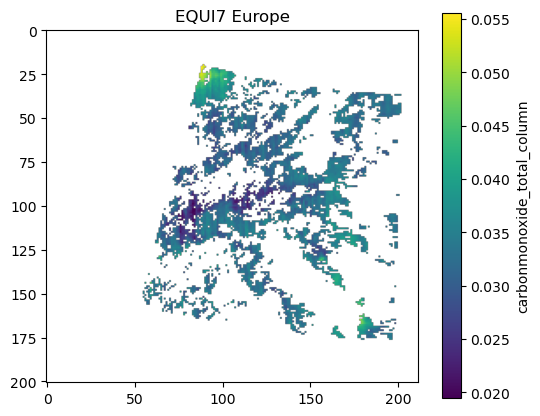

In [47]:
plt.figure(figsize=(6, 5))
plt.imshow(ds_equi7.carbonmonoxide_total_column, origin="upper")
plt.colorbar(label="carbonmonoxide_total_column")
plt.title("EQUI7 Europe")
plt.show()


## 11. Build final xarray Dataset

We attach **x/y coordinates**, **CRS**, and a **time dimension**.

In [48]:
ds_aut = ds_equi7.sel(x=slice(4500000,5390000), y=slice(1800000,1210000)).expand_dims({"time": [sensing_time]})


In [49]:
ds_aut

<xarray.Dataset> Size: 174kB
Dimensions:                                (time: 1, y: 60, x: 90)
Coordinates:
  * time                                   (time) datetime64[s] 8B 2024-08-17
  * y                                      (y) float64 480B 1.8e+06 ... 1.21e+06
  * x                                      (x) float64 720B 4.5e+06 ... 5.39e+06
Data variables:
    qa_value                               (time, y, x) float64 43kB nan ... nan
    carbonmonoxide_total_column            (time, y, x) float64 43kB nan ... nan
    carbonmonoxide_total_column_precision  (time, y, x) float64 43kB nan ... nan
    carbonmonoxide_total_column_corrected  (time, y, x) float64 43kB nan ... nan

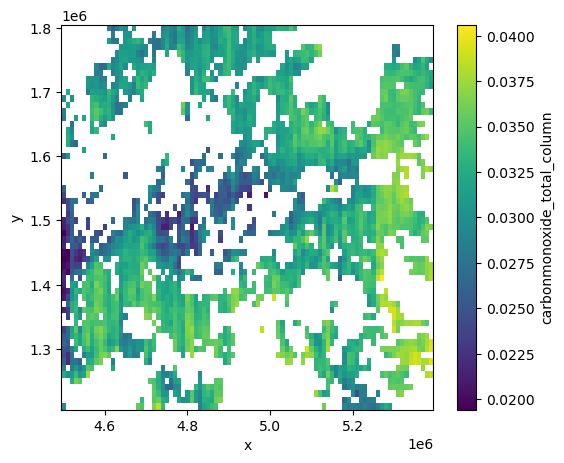

In [50]:
plt.figure(figsize=(6, 5))

plt.pcolormesh(
    ds_aut.x,
    ds_aut.y,
    ds_aut.carbonmonoxide_total_column.isel(time=0),
    shading="auto",
)

plt.colorbar(label="carbonmonoxide_total_column")
plt.xlabel("x")
plt.ylabel("y")
plt.show()
